<a href="https://colab.research.google.com/github/Amish-mavani/Hybrid-BERT-T5-with-Mixture-of-Experts/blob/main/model_SAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#start

In [ ]:
! pip install datasets
! pip install transformers
! pip install rouge-score nltk
! pip install evaluate
! pip install -U fsspec datasets
#! pip install python-docx

# library

In [ ]:
import re
import nltk
import requests
import transformers
import tensorflow as tf
#from transformers import AutoModel, AutoTokenizer
from transformers import BertModel, BertTokenizer, T5ForConditionalGeneration, T5Tokenizer, T5Config
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, AutoModelForQuestionAnswering, pipeline
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch
import evaluate
from transformers import DataCollatorForSeq2Seq
from torch.optim import AdamW
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset
import torch.nn.functional as F
from datasets import load_dataset, concatenate_datasets
from transformers import BertTokenizerFast, T5TokenizerFast, T5EncoderModel
from scipy.stats import pearsonr, spearmanr
from torch.nn import BCEWithLogitsLoss
from transformers.modeling_outputs import BaseModelOutput
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, accuracy_score
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model

In [ ]:
bert_model = BertModel.from_pretrained("bert-base-uncased").to(device).eval()
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

t5_tokenizer = T5Tokenizer.from_pretrained("t5-base")
t5_encoder = T5EncoderModel.from_pretrained("t5-base").to(device).eval()
t5_full = T5ForConditionalGeneration.from_pretrained("t5-base").to(device).eval()


In [ ]:
def tokenize_with_pad(tokenizer, word):
    tokens = tokenizer.encode(word, add_special_tokens=False)
    pad_id = tokenizer.pad_token_id
    if len(tokens) > 1:
        tokens = tokens[:1] + [pad_id] + tokens[1:]
    attention_mask = [1 if tok != pad_id else 0 for tok in tokens]
    return tokens, attention_mask

def get_aligned_embeddings(sentence):
    if isinstance(sentence, list):
        sentence = " ".join(sentence)
    words = sentence.strip().split()
    bert_word_embs = []
    t5_word_embs = []

    for word in words:
        b_ids, b_mask = tokenize_with_pad(bert_tokenizer, word)
        t_ids, t_mask = tokenize_with_pad(t5_tokenizer, word)

        max_len = max(len(b_ids), len(t_ids))

        if max_len == 0:  # Skip empty tokenizations
            continue

        def pad_to_len(ids, mask, pad_id, length):
            while len(ids) < length:
                ids.append(pad_id)
                mask.append(0)
            return ids, mask

        b_ids, b_mask = pad_to_len(b_ids, b_mask, bert_tokenizer.pad_token_id, max_len)
        t_ids, t_mask = pad_to_len(t_ids, t_mask, t5_tokenizer.pad_token_id, max_len)

        #b_ids = torch.tensor([b_ids]).to(device)       #float tensor may be mistakenly used
        #b_mask = torch.tensor([b_mask]).to(device)
        #t_ids = torch.tensor([t_ids]).to(device)
        #t_mask = torch.tensor([t_mask]).to(device)

        b_ids = torch.tensor([b_ids], dtype=torch.long).to(device)
        b_mask = torch.tensor([b_mask], dtype=torch.long).to(device)
        t_ids = torch.tensor([t_ids], dtype=torch.long).to(device)
        t_mask = torch.tensor([t_mask], dtype=torch.long).to(device)

        with torch.no_grad():
            b_out = bert_model(input_ids=b_ids, attention_mask=b_mask).last_hidden_state  # [1, L, 768]
            t_out = t5_encoder(input_ids=t_ids, attention_mask=t_mask).last_hidden_state  # [1, L, 768]

        # Remove batch dim: [1, L, 768] → [L, 768]
        b_out = b_out.squeeze(0)
        t_out = t_out.squeeze(0)

        # Masking: [L] → [L, 1]
        b_mask = b_mask.squeeze(0).unsqueeze(-1)
        t_mask = t_mask.squeeze(0).unsqueeze(-1)

        if b_mask.sum() > 0:
            b_avg = (b_out * b_mask).sum(dim=0) / b_mask.sum()
        else:
            b_avg = b_out.mean(dim=0)

        if t_mask.sum() > 0:
            t_avg = (t_out * t_mask).sum(dim=0) / t_mask.sum()
        else:
            t_avg = t_out.mean(dim=0)

        bert_word_embs.append(b_avg)
        t5_word_embs.append(t_avg)

    return torch.stack(bert_word_embs), torch.stack(t5_word_embs)

class EncoderFusion(nn.Module):
    def __init__(self, bert_dim=768, t5_dim=768):
        super().__init__()
        self.bert_proj = nn.Linear(bert_dim, t5_dim)
        self.fuse_proj = nn.Linear(t5_dim * 2, t5_dim)

    def forward(self, t5_embs, bert_embs):
        bert_proj = self.bert_proj(bert_embs)
        max_len = max(t5_embs.size(0), bert_proj.size(0))

        def pad(tensor, target_len):
            if tensor.size(0) < target_len:
                pad_len = target_len - tensor.size(0)
                pad_tensor = torch.zeros(pad_len, tensor.size(1), device=tensor.device)
                return torch.cat([tensor, pad_tensor], dim=0)
            return tensor

        t5_embs = pad(t5_embs, max_len)
        bert_proj = pad(bert_proj, max_len)

        fused = torch.cat([t5_embs, bert_proj], dim=-1)
        return self.fuse_proj(fused)

class PatchedT5(T5ForConditionalGeneration):
    def __init__(self, base_model, fused_hidden=None):
        super().__init__(base_model.config)
        self.load_state_dict(base_model.state_dict())
        #self.fused_hidden = fused_hidden.unsqueeze(0)
        self.fused_hidden = fused_hidden.unsqueeze(0) if fused_hidden is not None else None

    #def encode(self, *args, **kwargs):
    #    return self.fused_hidden
    def encode(self, *args, **kwargs):
        if self.fused_hidden is not None:
            return self.fused_hidden
        else:
            return super().get_encoder()(*args, **kwargs)


In [ ]:
class PatchedT5(T5ForConditionalGeneration):
    def __init__(self, base_model, fused_hidden=None):
        super().__init__(base_model.config)
        self.load_state_dict(base_model.state_dict())  # Initialize from base model
        self.fused_hidden = fused_hidden.unsqueeze(0) if fused_hidden is not None else None

    def encode(self, *args, **kwargs):
        if self.fused_hidden is not None:
            return self.fused_hidden
        else:
            return super().get_encoder()(*args, **kwargs)

    @classmethod
    def load(cls, base_model, path, fused_hidden=None, device=None):
        """
        Args:
            base_model: An instance of T5ForConditionalGeneration or from_pretrained.
            path: Path to .pt or .bin file containing saved weights.
            fused_hidden: Optional tensor to inject after loading.
            device: Optional torch.device to move model to (e.g., 'cuda').
        """
        model = cls(base_model, fused_hidden=fused_hidden)
        model.load_state_dict(torch.load(path, map_location=device))
        if device is not None:
            model = model.to(device)
        return model

In [ ]:
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

# sum training

## cnn sum

In [ ]:
sum_raw_datasets = load_dataset("cnn_dailymail", "1.0.0")
train_dataset_raw = sum_raw_datasets["train"].select(range(370))

def preprocess_function(example):
    input_text = "summarize: " + example["article"]
    target_text = example["highlights"]
    return {"input_text": input_text, "target_text": target_text}

dataset = train_dataset_raw.map(preprocess_function)

In [ ]:
train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

fusion = EncoderFusion().to(device)
fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_summarize.pt"))
fusion.train()

loss_list = []
step_list = []
epoch_list = []

patched_t5 = None
#optimizer = AdamW(patched_t5.parameters(), lr=1e-5)
i = 1
num_epochs = 3
max_retries = 3

for epoch in range(num_epochs):
  for batch in train_dataloader:
    success = False
    retries = 0
    while not success and retries < max_retries:
     try:
        if i % 5 == 1:
          torch.cuda.empty_cache()
          gc.collect()
          print("[INFO] Cleared GPU cache.")

        input_texts = batch['input_text']
        target_texts = batch['target_text']

        inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        targets = t5_tokenizer(target_texts, padding=True, truncation=True, return_tensors="pt").to(device)

        bert_embs, t5_embs = get_aligned_embeddings(input_texts)
        bert_embs, t5_embs = bert_embs.to(device), t5_embs.to(device)

        fused_hidden = fusion(t5_embs, bert_embs)

        if patched_t5 is None:
          patched_t5 = PatchedT5.load(t5_full, "modelSAGE/patched_t5_summarize.pt", fused_hidden=fused_hidden).to(device)
          patched_t5.train()
          #patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
          optimizer = AdamW(patched_t5.parameters(), lr=1e-5)

        patched_t5.fused_hidden = fused_hidden.detach().to(device)

        outputs = patched_t5(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            labels=targets.input_ids)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(patched_t5.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch {epoch}, Step {i-1}, Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
        step_list.append(i - 1)
        epoch_list.append(epoch)

        del inputs, targets, bert_embs, t5_embs, fused_hidden, outputs, loss
        torch.cuda.empty_cache()
        gc.collect()
        success = True  # Mark as passed
        i += 1

     except torch.cuda.OutOfMemoryError:
      print(f"[OOM ERROR] Step {i}, Retry {retries + 1} of {max_retries}")
      allocated = torch.cuda.memory_allocated() / 1e9
      reserved = torch.cuda.memory_reserved() / 1e9
      print(f"[GPU Memory] Allocated: {allocated:.2f} GB | Reserved: {reserved:.2f} GB")
      torch.cuda.empty_cache()
      gc.collect()
      retries += 1

      if retries >= max_retries:
        print("[FATAL] Skipping this sample due to persistent OOM.")
        break  # Skip this sample and go to next one

     except Exception as e:
      print(f"[ERROR] Unexpected error at step {i}: {e}")
      torch.cuda.empty_cache()
      gc.collect()
      break

torch.save(patched_t5.state_dict(), "modelSAGE/patched_t5_summarize.pt")
torch.save(fusion.state_dict(), "modelSAGE/encoder_fusion_summarize.pt")
print("summarize Model saved.")


### results

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
epoch_loss_dict = defaultdict(list)

for epoch, loss in zip(epoch_list, loss_list):
    epoch_loss_dict[epoch].append(loss)

epoch_avg_losses = []
epochs = []

for epoch in sorted(epoch_loss_dict.keys()):
    losses = epoch_loss_dict[epoch]
    avg_loss = sum(losses) / len(losses)
    epoch_avg_losses.append(avg_loss)
    epochs.append(epoch)
    print(f"Epoch {epoch}: Average Loss = {avg_loss:.4f}")


Epoch 0: Average Loss = 1.4171
Epoch 1: Average Loss = 1.3212
Epoch 2: Average Loss = 1.2427


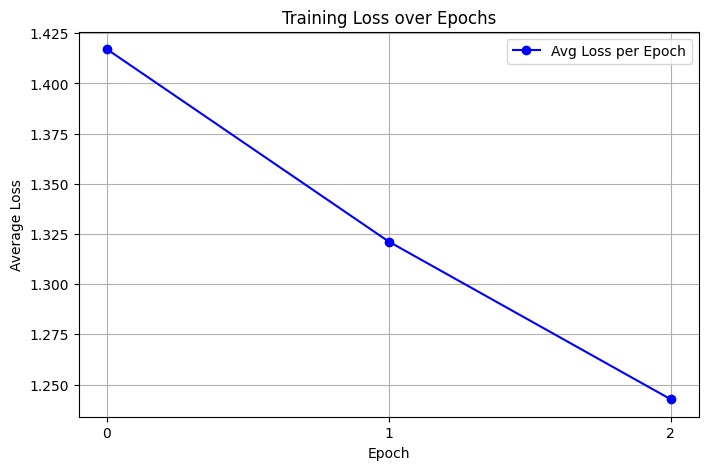

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, epoch_avg_losses, marker='o', color='blue', label="Avg Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss over Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig("epoch_loss_curve.png")
plt.show()



In [ ]:
rouge_metric = evaluate.load("rouge")
fusion = EncoderFusion().to(device)
validation_set = sum_raw_datasets["train"].select(range(25))
predictions = []
references = []

for batch in tqdm(validation_set, desc="Evaluating"):
  input_texts = batch["article"]
  target_texts = batch["highlights"]

  inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)

  with torch.no_grad():
    bert_embs, t5_embs = get_aligned_embeddings(input_texts)
    fused_hidden = fusion(t5_embs, bert_embs)
    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
    output_ids = patched_t5.generate(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, max_length=155)
    generated_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_text)
  references.append(target_texts)

rouge_results = rouge_metric.compute(
    predictions = predictions,
    references = references
    )

print(f"\nROUGE-1: {rouge_results['rouge1']}")
print(f"ROUGE-2: {rouge_results['rouge2']}")
print(f"ROUGE-L: {rouge_results['rougeL']}")
print(f"ROUGE-L Sum: {rouge_results['rougeLsum']}")

Evaluating: 100%|██████████| 25/25 [06:46<00:00, 16.26s/it]


ROUGE-1: 0.3352279590161554
ROUGE-2: 0.13602990595594414
ROUGE-L: 0.24192644811105307
ROUGE-L Sum: 0.2403376316696564


In [ ]:
def load_expert(patched_t5_path, fusion_path):
    fusion = EncoderFusion().to(device)
    fusion.load_state_dict(torch.load(fusion_path, map_location=torch.device('cpu')))
    fusion.eval()

    t5_base = T5ForConditionalGeneration.from_pretrained("t5-base").to(device)
    patched_t5 = PatchedT5(t5_base).to(device)
    patched_t5.load_state_dict(torch.load(patched_t5_path, map_location=torch.device('cpu')))
    patched_t5.eval()

    return fusion, patched_t5

fusion, patched_t5 = load_expert("modelSAGE/patched_t5_summarize.pt", "modelSAGE/encoder_fusion_summarize.pt")

In [ ]:
#final check
rouge_metric = evaluate.load("rouge")
#fusion = EncoderFusion().to(device)
#sum_raw_datasets = load_dataset("cnn_dailymail", "1.0.0")
validation_set = sum_raw_datasets["validation"].select(range(25))
predictions = []
references = []

for batch in tqdm(validation_set, desc="Evaluating"):
  input_texts = batch["article"]
  target_texts = batch["highlights"]

  inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
  #inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt")
  #inputs = {k: v.to(torch.long).to(device) for k, v in inputs.items()}

  with torch.no_grad():
    bert_embs, t5_embs = get_aligned_embeddings(input_texts)
    fused_hidden = fusion(t5_embs, bert_embs)
    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
    output_ids = patched_t5.generate(
        input_ids=inputs.input_ids,
        attention_mask=inputs.attention_mask,
        #input_ids=inputs["input_ids"],
        #attention_mask=inputs["attention_mask"],
        max_length=155)
    generated_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_text)
  references.append(target_texts)
  del bert_embs, t5_embs, fused_hidden, patched_t5, inputs, output_ids
  torch.cuda.empty_cache()
  gc.collect()

rouge_results = rouge_metric.compute(
    predictions = predictions,
    references = references
    )

print(f"\nROUGE-1: {rouge_results['rouge1']}")
print(f"ROUGE-2: {rouge_results['rouge2']}")
print(f"ROUGE-L: {rouge_results['rougeL']}")
print(f"ROUGE-L Sum: {rouge_results['rougeLsum']}")

Evaluating: 100%|██████████| 25/25 [06:26<00:00, 15.45s/it]



ROUGE-1: 0.2757849304634943
ROUGE-2: 0.08424566653207824
ROUGE-L: 0.18692143740959932
ROUGE-L Sum: 0.18779801284390923


In [ ]:
rouge_metric = evaluate.load("rouge")
#fusion = EncoderFusion().to(device)
validation_set = sum_raw_datasets["train"].select(range(25))
predictions = []
references = []

for batch in tqdm(validation_set, desc="Evaluating"):
  input_texts = batch["article"]
  target_texts = batch["highlights"]

  inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)

  with torch.no_grad():
    bert_embs, t5_embs = get_aligned_embeddings(input_texts)
    fused_hidden = fusion(t5_embs, bert_embs)
    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
    output_ids = patched_t5.generate(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, max_length=155)
    generated_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_text)
  references.append(target_texts)

rouge_results = rouge_metric.compute(
    predictions = predictions,
    references = references
    )

print(f"\nROUGE-1: {rouge_results['rouge1']}")
print(f"ROUGE-2: {rouge_results['rouge2']}")
print(f"ROUGE-L: {rouge_results['rougeL']}")
print(f"ROUGE-L Sum: {rouge_results['rougeLsum']}")

Evaluating: 100%|██████████| 25/25 [08:31<00:00, 20.44s/it]


ROUGE-1: 0.2918731353119992
ROUGE-2: 0.09737607088001944
ROUGE-L: 0.19754820893631608
ROUGE-L Sum: 0.19672663364300538


## ted sum

In [ ]:
import kagglehub
path = kagglehub.dataset_download("thegupta/ted-talk")
print("Path to dataset files:", path)

100%|██████████| 26.8M/26.8M [00:00<00:00, 147MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thegupta/ted-talk/versions/2


In [ ]:
import pandas as pd

file_path = path+'/TED_Talk.csv'

df = pd.read_csv(file_path)
print(df.head())

In [ ]:
df.transcript[0]

In [ ]:
df.talk__description[0]

In [ ]:
from datasets import Dataset
ted_dataset = df[['talk__name','transcript', 'talk__description']].fillna("")

def preprocess_function(example):
    input_text = "summarize:" + str(example["transcript"])
    target_text = str(example["talk__description"])
    return pd.Series({"input_text": input_text, "target_text": target_text})

dataset = ted_dataset.apply(preprocess_function, axis=1)
dataset = Dataset.from_pandas(dataset)

In [ ]:
def train_model():
    train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
    fusion = EncoderFusion().to(device)
    patched_t5 = None
    optimizer = None
    i = 1
    num_epochs = 3

    for epoch in range(num_epochs):
        for batch in train_dataloader:

            if i % 5 == 1:
              torch.cuda.empty_cache()
              gc.collect()
              print("[INFO] Cleared GPU cache.")
            i += 1

            input_texts = batch['input_text']
            target_texts = batch['target_text']

            inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
            targets = t5_tokenizer(target_texts, padding=True, truncation=True, return_tensors="pt").to(device)

            for input_text in input_texts:
                bert_embs, t5_embs = get_aligned_embeddings(input_text)

                fused_hidden = fusion(t5_embs, bert_embs)
                if patched_t5 is None:
                    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
                    optimizer = AdamW(patched_t5.parameters(), lr=1e-5)  # Initialize optimizer after patched_t5

                outputs = patched_t5(
                    input_ids=inputs.input_ids,
                    attention_mask=inputs.attention_mask,
                    labels=targets.input_ids)

                loss = outputs.loss
                loss.backward()

                optimizer.step()
                optimizer.zero_grad()

                print(f"Epoch {epoch}, Step {i}, Loss: {loss.item():.4f}")
                del bert_embs, t5_embs, fused_hidden, outputs, loss
                torch.cuda.empty_cache()
                gc.collect()

            del inputs, targets
            torch.cuda.empty_cache()
            gc.collect()

    torch.save(patched_t5.state_dict(), "modelSAGE/patched_t5_summarize_ted.pt")
    torch.save(fusion.state_dict(), "modelSAGE/encoder_fusion_summarize_ted.pt")
    print("summarize Model saved.")

if __name__ == "__main__":
    train_model()


### results

# model

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased").to(device).eval()

t5_tokenizer = T5Tokenizer.from_pretrained("t5-base")
t5_encoder = T5EncoderModel.from_pretrained("t5-base").to(device).eval()
t5_full = T5ForConditionalGeneration.from_pretrained("t5-base").to(device).eval()

# QA training

## short QA

In [ ]:
sqa_raw_datasets = load_dataset("squad", trust_remote_code=True)
train_dataset_raw = sqa_raw_datasets["train"].select(range(73))

def preprocess_function(example):
    input_text = f"question: {example['question']} context: {example['context']}"
    target_text = example["answers"]["text"][0] if example["answers"]["text"] else ""
    return {"input_text": input_text, "target_text": target_text}

dataset = train_dataset_raw.map(preprocess_function)

In [ ]:
train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

fusion = EncoderFusion().to(device)
fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_sqa.pt"))
fusion.train()

loss_list = []
step_list = []
epoch_list = []

patched_t5 = None
optimizer = None
i = 1

num_epochs = 3
max_retries = 3

for epoch in range(num_epochs):
    for batch in train_dataloader:
        if i % 5 == 1:
              torch.cuda.empty_cache()
              gc.collect()
              print("[INFO] Cleared GPU cache.")
        i += 1

        input_texts = batch['input_text']
        target_texts = batch['target_text']

        inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        targets = t5_tokenizer(target_texts, padding=True, truncation=True, return_tensors="pt").to(device)

        bert_embs, t5_embs = get_aligned_embeddings(input_texts)

        bert_embs = bert_embs.to(device)
        t5_embs = t5_embs.to(device)

        fused_hidden = fusion(t5_embs, bert_embs)
        if patched_t5 is None:
          patched_t5 = PatchedT5.load(t5_full, "modelSAGE/patched_t5_sqa.pt", fused_hidden=fused_hidden).to(device)
          patched_t5.train()
          #patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
          optimizer = AdamW(patched_t5.parameters(), lr=1e-5)

        patched_t5.fused_hidden = fused_hidden.detach().to(device)

        outputs = patched_t5(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            labels=targets.input_ids)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(patched_t5.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch {epoch}, Step {i-1}, Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
        step_list.append(i - 1)
        epoch_list.append(epoch)
        del inputs, targets, bert_embs, t5_embs, fused_hidden, outputs, loss
        torch.cuda.empty_cache()
        gc.collect()

torch.save(patched_t5.state_dict(), "modelSAGE/patched_t5_sqa.pt")
torch.save(fusion.state_dict(), "modelSAGE/encoder_fusion_sqa.pt")
print("Model saved.")


In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
epoch_loss_dict = defaultdict(list)

for epoch, loss in zip(epoch_list, loss_list):
    epoch_loss_dict[epoch].append(loss)

epoch_avg_losses = []
epochs = []

for epoch in sorted(epoch_loss_dict.keys()):
    losses = epoch_loss_dict[epoch]
    avg_loss = sum(losses) / len(losses)
    epoch_avg_losses.append(avg_loss)
    epochs.append(epoch)
    print(f"Epoch {epoch}: Average Loss = {avg_loss:.4f}")


Epoch 0: Average Loss = 0.0822
Epoch 1: Average Loss = 0.0379
Epoch 2: Average Loss = 0.0340


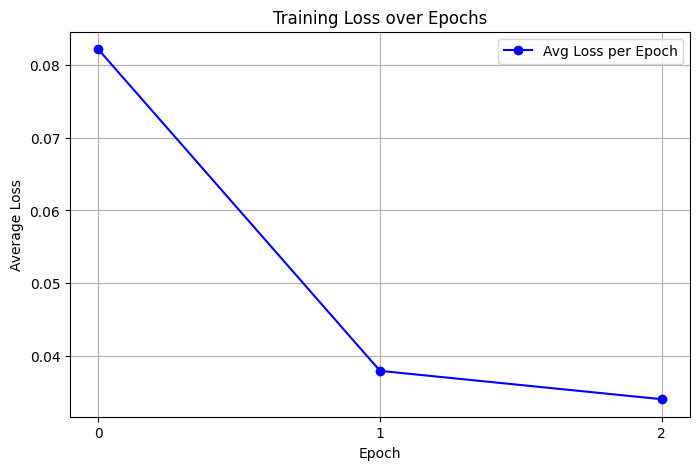

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, epoch_avg_losses, marker='o', color='blue', label="Avg Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss over Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig("epoch_loss_curve.png")
plt.show()


### results

### Extractive QA

In [ ]:
from collections import Counter
import string
squad_version = "squad"  # or "squad_v2" for version 2.0
metric = evaluate.load("squad" if squad_version == "squad" else "squad_v2")

def normalize_answer(s):
    """Lower text and remove punctuation, articles and extra whitespace."""
    def remove_articles(text): return ' '.join([w for w in text.split() if w not in ['a', 'an', 'the']])
    def white_space_fix(text): return ' '.join(text.split())
    def remove_punc(text): return ''.join(ch for ch in text if ch not in string.punctuation)
    def lower(text): return text.lower()
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_precision_recall(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0, 0.0

    precision = num_same / len(prediction_tokens)
    recall = num_same / len(ground_truth_tokens)
    return precision, recall

validation_set = sqa_raw_datasets["train"].select(range(25))

predictions = []
references = []
precisions, recalls, answer_lengths = [], [], []

for sample in tqdm(validation_set, desc="Evaluating"):
    context = sample["context"]
    question = sample["question"]
    id_ = sample["id"]

    input_text = f"question: {question} context: {context}"
    inputs = t5_tokenizer(input_text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
      bert_embs, t5_embs = get_aligned_embeddings(input_text)
      fused_hidden = fusion(t5_embs, bert_embs)
      patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
      output_ids = patched_t5.generate(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, max_length=64)
      result = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
      predictions.append({"id": id_, "prediction_text": result})

    reference = sample["answers"]["text"][0] if sample["answers"]["text"] else ""
    references.append({"id": id_, "answers": sample["answers"]})

    precision, recall = compute_precision_recall(result, reference)
    precisions.append(precision)
    recalls.append(recall)
    answer_lengths.append(len(result.split()))

results = metric.compute(predictions=predictions, references=references)
print(f"\n--- Evaluation Results on {squad_version} ---")
print(f"Exact Match (EM): {results['exact_match']:.2f}")
print(f"F1 Score: {results['f1']:.2f}")
print(f"Average Precision: {100 * sum(precisions) / len(precisions):.2f}")
print(f"Average Recall: {100 * sum(recalls) / len(recalls):.2f}")
print(f"Average Answer Length: {sum(answer_lengths) / len(answer_lengths):.2f} tokens")


Evaluating: 100%|██████████| 25/25 [03:59<00:00,  9.59s/it]
--- Evaluation Results on squad ---
Exact Match (EM): 80.00
F1 Score: 88.00
Average Precision: 90.00
Average Recall: 88.00
Average Answer Length: 2.64 tokens


### Abstractive QA

In [ ]:
rouge_metric = evaluate.load("rouge")
fusion = EncoderFusion().to(device)

validation_set = sqa_raw_datasets["train"].select(range(25))

predictions = []
references = []

for batch in tqdm(validation_set, desc="Evaluating"):
  context = batch["context"]
  question = batch["question"]
  id_ = batch["id"]

  input_text = f"question: {question} context: {context}"
  inputs = t5_tokenizer(input_text, return_tensors="pt", truncation=True, padding=True).to(device)

  with torch.no_grad():
    bert_embs, t5_embs = get_aligned_embeddings(input_text)
    fused_hidden = fusion(t5_embs, bert_embs)
    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
    output_ids = patched_t5.generate(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, max_length=155)
    generated_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_text)
  reference_answer = batch["answers"]["text"][0] if batch["answers"]["text"] else ""
  references.append(reference_answer)

rouge_results = rouge_metric.compute(
    predictions = predictions,
    references = references
    )

print(f"\nROUGE-1: {rouge_results['rouge1']}")
print(f"ROUGE-2: {rouge_results['rouge2']}")
print(f"ROUGE-L: {rouge_results['rougeL']}")

Evaluating: 100%|██████████| 25/25 [03:19<00:00,  8.00s/it]
ROUGE-1: 0.9233939393939394
ROUGE-2: 0.5111111111111112
ROUGE-L: 0.9230303030303031


In [ ]:
for i in range(25):
  print(i, "\n", predictions[i],"\n",references[i])

## long QA

In [ ]:
eli5 = load_dataset("eli5", split="train_asks[:100]")
train_dataset_raw = eli5.select(range(555))

def preprocess_function(example):
    if not example["answers"]["text"]:
        return {"input_text": "", "target_text": ""}

    question = example["title"]
    context = example["selftext"] if example["selftext"] else "No context provided"
    answer = example["answers"]["text"][0]

    input_text = f"question: {question} context: {context}"
    target_text = answer

    return {"input_text": input_text, "target_text": target_text}

qa_dataset = train_dataset_raw.map(preprocess_function)
qa_dataset = qa_dataset.filter(lambda x: x["input_text"] != "" and x["target_text"] != "")


In [ ]:
train_dataloader = DataLoader(qa_dataset, batch_size=1, shuffle=True)
fusion = EncoderFusion().to(device)
#fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_sqa_long.pt"))
#fusion.train()
loss_list = []
step_list = []
epoch_list = []
patched_t5 = None
optimizer = None
i = 1
num_epochs = 3

for epoch in range(num_epochs):
    for batch in train_dataloader:
        if i % 5 == 1:
              torch.cuda.empty_cache()
              gc.collect()
              print("[INFO] Cleared GPU cache.")
        i += 1

        input_texts = batch['input_text']
        target_texts = batch['target_text']

        inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        targets = t5_tokenizer(target_texts, padding=True, truncation=True, return_tensors="pt").to(device)

        bert_embs, t5_embs = get_aligned_embeddings(input_text)

        bert_embs = bert_embs.to(device)
        t5_embs = t5_embs.to(device)

        fused_hidden = fusion(t5_embs, bert_embs)

        if patched_t5 is None:
          #patched_t5 = PatchedT5.load(t5_full, "modelSAGE/patched_t5_sqa_long.pt", fused_hidden=fused_hidden).to(device)
          #patched_t5.train()
          patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
          optimizer = AdamW(patched_t5.parameters(), lr=1e-5)

        patched_t5.fused_hidden = fused_hidden.detach().to(device)

        outputs = patched_t5(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            labels=targets.input_ids)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(patched_t5.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()

        print(f"Epoch {epoch}, Step {i-1}, Loss: {loss.item():.4f}")
        loss_list.append(loss.item())
        step_list.append(i - 1)
        epoch_list.append(epoch)

        del inputs, targets, bert_embs, t5_embs, fused_hidden, outputs, loss
        torch.cuda.empty_cache()
        gc.collect()

torch.save(patched_t5.state_dict(), "modelSAGE/patched_t5_sqa_long.pt")
torch.save(fusion.state_dict(), "modelSAGE/encoder_fusion_sqa_long.pt")
print("Model saved.")


In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
epoch_loss_dict = defaultdict(list)

for epoch, loss in zip(epoch_list, loss_list):
    epoch_loss_dict[epoch].append(loss)

epoch_avg_losses = []
epochs = []

for epoch in sorted(epoch_loss_dict.keys()):
    losses = epoch_loss_dict[epoch]
    avg_loss = sum(losses) / len(losses)
    epoch_avg_losses.append(avg_loss)
    epochs.append(epoch)
    print(f"Epoch {epoch}: Average Loss = {avg_loss:.4f}")


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, epoch_avg_losses, marker='o', color='blue', label="Avg Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss over Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig("epoch_loss_curve.png")
plt.show()

### results

In [ ]:

rouge_metric = evaluate.load("rouge")
fusion = EncoderFusion().to(device)

train_dataset_raw = eli5.select(range(25))
qa_dataset = train_dataset_raw.map(preprocess_function)
validation_set = qa_dataset.filter(lambda x: x["input_text"] != "" and x["target_text"] != "")

predictions = []
references = []

for batch in tqdm(validation_set, desc="Evaluating"):
  input_text = batch["input_text"]
  reference = batch["target_text"]

  inputs = t5_tokenizer(input_text, return_tensors="pt", truncation=True, padding=True).to(device)

  with torch.no_grad():
    bert_embs, t5_embs = get_aligned_embeddings(input_text)
    fused_hidden = fusion(t5_embs, bert_embs)
    patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
    output_ids = patched_t5.generate(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, max_length=155)
    generated_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_text)
  references.append(reference)

rouge_results = rouge_metric.compute(
    predictions = predictions,
    references = references
    )

print(f"\nROUGE-1: {rouge_results['rouge1']}")
print(f"ROUGE-2: {rouge_results['rouge2']}")
print(f"ROUGE-L: {rouge_results['rougeL']}")

# QG training

In [ ]:
sqa_raw_datasets = load_dataset("squad", trust_remote_code=True)
train_dataset_raw = sqa_raw_datasets["train"].select(range(255))

def preprocess_function(example):
    input_text = f"generate question:{example['answers']['text'][0]} context: {example['context']}"
    target_text = example['question']
    return {"input_text": input_text, "target_text": target_text}

dataset = train_dataset_raw.map(preprocess_function)

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Map:   0%|          | 0/555 [00:00<?, ? examples/s]

In [ ]:
train_dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
fusion = EncoderFusion().to(device)
patched_t5 = None
optimizer = None
i = 1

num_epochs = 5
for epoch in range(num_epochs):
    for batch in train_dataloader:
        if i % 5 == 1:
              torch.cuda.empty_cache()
              gc.collect()
              print("[INFO] Cleared GPU cache.")
        i += 1

        input_texts = batch['input_text']
        target_texts = batch['target_text']

        inputs = t5_tokenizer(input_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        targets = t5_tokenizer(target_texts, padding=True, truncation=True, return_tensors="pt").to(device)

        for input_text in input_texts:
            bert_embs, t5_embs = get_aligned_embeddings(input_text)

            fused_hidden = fusion(t5_embs, bert_embs)
            if patched_t5 is None:
                patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
                optimizer = AdamW(patched_t5.parameters(), lr=1e-5)

            outputs = patched_t5(input_ids=inputs.input_ids, attention_mask=inputs.attention_mask, labels=targets.input_ids)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"Epoch {epoch+1}, Step {i-1}, Loss: {loss.item():.4f}")
            del bert_embs, t5_embs, fused_hidden, outputs, loss
            torch.cuda.empty_cache()
            gc.collect()

        del inputs, targets
        torch.cuda.empty_cache()
        gc.collect()

torch.save(patched_t5.state_dict(), "modelSAGE/patched_t5_sqg.pt")
torch.save(fusion.state_dict(), "modelSAGE/encoder_fusion_sqg.pt")
print("Model saved.")


## results

In [ ]:
metric = evaluate.load("bleu")

validation_set = sqa_raw_datasets["train"].select(range(15))
predictions = []
references = []

for sample in (validation_set):
    context_text = sample["context"]
    reference_question = sample["question"]
    answers = sample["answers"]

    input_text = f"generate question:{answers['text'][0]} context:{context_text}"
    inputs = t5_tokenizer(input_text, return_tensors="pt", truncation=True, padding=True).to(device)

    with torch.no_grad():
        bert_embs, t5_embs = get_aligned_embeddings(input_text)
        fused_hidden = fusion(t5_embs, bert_embs)
        patched_t5 = PatchedT5(t5_full, fused_hidden).to(device)
        output_ids = patched_t5.generate(input_ids=inputs.input_ids,
                                         attention_mask=inputs.attention_mask,
                                         max_length=64,
                                         num_beams=4,
                                         early_stopping=True)
        result = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(result.lower().strip())
    references.append(reference_question.lower().strip())

print("\n", predictions)
print("\n", references)

results = metric.compute(predictions=predictions, references=references)

print(f"\n--- Evaluation Results with BLEU ---")
print(f"BLEU Score: {results['bleu'] * 100:.2f}")

rouge = evaluate.load("rouge")
#predictions = [pred.lower().strip() for pred in predictions]
#references = [ref[0].lower().strip() for ref in references]
rouge_results = rouge.compute(predictions=predictions, references=references)

print("\n--- ROUGE Evaluation ---")
print(f"ROUGE-1:  {rouge_results['rouge1']}")
print(f"ROUGE-2:  {rouge_results['rouge2']}")
print(f"ROUGE-L:  {rouge_results['rougeL']}")


 ['mary reputedly appeared to saint bernadette soubirous in 1858', 'a copper statue of christ with arms', 'immediately behind the basilica is the grotto', 'grotto', "atop the main building's gold dome", 'begun as a one-page journal', 'nine student-run outlets include three newspapers, both a radio and television station, and several magazines and journals', "published daily and mainly reporting university and other news, and staffed by students from both notre dame and saint mary's college", 'three newspapers, both a radio and television station, and several magazines and journals', '1987, when some students believed that the observer began to show a conservative bias, the conservative paper irish rover went into production', 'congregation of holy cross', 'moreau seminary, is located on the campus across st. joseph lake', 'the oldest building on campus', 'reside in fatima house (a former retreat center), holy cross house, as well as columba hall', 'while not catholic, buechner has pra

# moe

In [ ]:
def load_expert(patched_t5_path, fusion_path):
    fusion = EncoderFusion().to(device)
    fusion.load_state_dict(torch.load(fusion_path))
    fusion.eval()

    t5_base = T5ForConditionalGeneration.from_pretrained("t5-base").to(device)
    patched_t5 = PatchedT5(t5_base).to(device)
    patched_t5.load_state_dict(torch.load(patched_t5_path))
    patched_t5.eval()

    return fusion, patched_t5


## Router Module

In [ ]:
class LearnedRouter(nn.Module):
    def __init__(self, input_dim=768, num_experts=2):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_experts)
        )

    def forward(self, fused_hidden):
        pooled = fused_hidden.mean(dim=1)  # [batch, hidden]
        logits = self.classifier(pooled)   # [batch, num_experts]
        probs = torch.softmax(logits, dim=-1)
        return probs, logits  # return both for supervised routing loss
        #pooled = fused_hidden.mean(dim=1)
        #return torch.softmax(self.net(pooled), dim=-1)  # [batch, num_experts]

## MoE Model with Soft Routing


In [ ]:
class MoEModel(nn.Module):
    def __init__(self, expert_models, router):
        super().__init__()
        self.expert_models = expert_models
        self.router = router

    def forward(self, input_ids, attention_mask, fused_hidden, labels=None, task_labels=None):
        routing_probs, routing_logits = self.router(fused_hidden)  # [batch, num_experts]
        expert_outputs = []

        for i, expert in enumerate(self.expert_models):
            output = expert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                encoder_outputs=(fused_hidden,),
                labels=labels
            )
            expert_outputs.append(output.logits)

        stacked_logits = torch.stack(expert_outputs, dim=0)  # [num_experts, batch, seq, vocab]
        routing_probs = routing_probs.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, num_experts]
        weighted_logits = (routing_probs * stacked_logits.permute(1, 2, 3, 0)).sum(-1)

        return weighted_logits, routing_logits  # also return router logits for loss


In [ ]:
class MoEModel(nn.Module):
    def __init__(self, expert_models, router):
        super().__init__()
        self.expert_models = nn.ModuleList(expert_models)  # [summ_model, qa_model]
        self.router = router

    def forward(self, input_ids, attention_mask, fused_hidden, labels=None, task_labels=None):
        routing_probs, routing_logits = self.router(fused_hidden)  # [batch, num_experts]
        expert_outputs = []

        for i, expert in enumerate(self.expert_models):
            output = expert(
                input_ids=input_ids,
                attention_mask=attention_mask,
                encoder_outputs=(fused_hidden,),
                labels=labels
            )
            expert_outputs.append(output.logits)

        stacked_logits = torch.stack(expert_outputs, dim=0)  # [num_experts, batch, seq, vocab]
        routing_probs = routing_probs.unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, num_experts]
        weighted_logits = (routing_probs * stacked_logits.permute(1, 2, 3, 0)).sum(-1)

        return weighted_logits, routing_logits  # also return router logits for loss


    def generate(self, input_ids, attention_mask, fused_hidden, max_length=64, num_beams=4):
        """
        Perform generation using the routed expert.
        `fused_hidden` should be pre-selected for the expert based on routing decision.
        """
        # For now, assume batch size = 1
        assert fused_hidden.size(0) == 1, "generate() currently supports batch_size=1 only."

        # Route the input using the router
        with torch.no_grad():
            probs, routing_logits = self.router(fused_hidden)  # [1, num_experts]
            selected_expert = torch.argmax(routing_logits, dim=-1).item()

        expert_model = self.expert_models[selected_expert]
        expert_model.fused_hidden = fused_hidden  # Inject hidden representation

        output_ids = expert_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True
        )

        return output_ids


## training

In [ ]:
sum_raw_datasets = load_dataset("cnn_dailymail", "1.0.0")
sqa_raw_datasets = load_dataset("squad", trust_remote_code=True)

#sum_dataset_raw = sum_raw_datasets["train"].select(range(20))
#sqa_dataset_raw = sqa_raw_datasets["train"].select(range(20))

In [ ]:
import random
random_indices = random.sample(range(1000), 50)

sum_dataset_raw = sum_raw_datasets["train"].select(random_indices)
sqa_dataset_raw = sqa_raw_datasets["train"].select(random_indices)

def preprocess_function_sum(example):
    input_text = "summarize: " + example["article"]
    target_text = example["highlights"]
    task_label = 0
    return {"input_text": input_text, "target_text": target_text, "task_label": task_label}

def preprocess_function_QA(example):
    input_text = f"question: {example['question']} context: {example['context']}"
    target_text = example["answers"]["text"][0] if example["answers"]["text"] else ""
    task_label = 1
    return {"input_text": input_text, "target_text": target_text, "task_label": task_label}

sum_dataset = sum_dataset_raw.map(preprocess_function_sum)
qa_dataset = sqa_dataset_raw.map(preprocess_function_QA)

combined_dataset = concatenate_datasets([sum_dataset, qa_dataset])
combined_dataset = combined_dataset.shuffle(seed=42)

combined_dataset = combined_dataset.remove_columns(
    [col for col in combined_dataset.column_names if col not in ["input_text", "target_text", "task_label"]]
)

train_dataloader = DataLoader(combined_dataset, batch_size=1, shuffle=True)

print(combined_dataset[5])

In [ ]:
from collections import Counter
print(Counter(combined_dataset['task_label']))

Counter({1: 50, 0: 50})


In [ ]:
summ_fusion, summ_model = load_expert("modelSAGE/patched_t5_summarize.pt", "modelSAGE/encoder_fusion_summarize.pt")
qa_fusion, qa_model = load_expert("modelSAGE/patched_t5_sqa.pt", "modelSAGE/encoder_fusion_sqa.pt")

In [ ]:
router = LearnedRouter().to(device)

moe_model = MoEModel([summ_model, qa_model], router).to(device)
optimizer = torch.optim.Adam(moe_model.parameters(), lr=3e-5)
criterion = nn.CrossEntropyLoss(ignore_index=t5_tokenizer.pad_token_id)

router_loss_fn = nn.CrossEntropyLoss()

loss_list = []
gen_loss_list = []
router_loss_list = []
step_list = []
epoch_list = []

i = 1
num_epochs = 3
for epoch in range(num_epochs):
   for batch in train_dataloader:

      if i % 5 == 1:
        torch.cuda.empty_cache()
        gc.collect()
        print("[INFO] Cleared GPU cache.")
      i += 1

      input_texts = batch['input_text']
      target_texts = batch['target_text']
      task_labels = batch['task_label']  # 0: summarization, 1: qa

      input_ids = t5_tokenizer(input_texts, return_tensors="pt", padding=True, truncation=True).input_ids.to(device)
      target_ids = t5_tokenizer(target_texts, return_tensors="pt", padding=True, truncation=True).input_ids.to(device)

      attention_mask = (input_ids != t5_tokenizer.pad_token_id).long().to(device)

      fusion_module = summ_fusion if task_labels[0] == 0 else qa_fusion

      bert_embs, t5_embs = get_aligned_embeddings(input_texts)

      fused_hidden = fusion_module(t5_embs.to(device), bert_embs.to(device)).detach()

      if fused_hidden.dim() == 2:  # [seq_len, 768]
          fused_hidden = fused_hidden.unsqueeze(0)  # → [1, seq_len, 768]

      logits, routing_logits = moe_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            fused_hidden=fused_hidden,
            labels=target_ids,
            task_labels=task_labels
        )

      gen_loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))

        # Supervised router loss
      task_labels_tensor = torch.tensor(task_labels, dtype=torch.long, device=device)
      router_loss = router_loss_fn(routing_logits, task_labels_tensor)

        # Combine losses
      total_loss = gen_loss + 0.5 * router_loss  # λ=0.5 is tunable
      total_loss.backward()
      torch.nn.utils.clip_grad_norm_(moe_model.parameters(), max_norm=1.0)
      optimizer.step()
      optimizer.zero_grad()

      print(f"Epoch {epoch}, Step {i}, Loss: {total_loss.item():.4f} (Gen: {gen_loss.item():.4f}, Router: {router_loss.item():.4f})")
      loss_list.append(total_loss.item())          # Combined total loss
      step_list.append(i - 1)
      epoch_list.append(epoch)

      gen_loss_list.append(gen_loss.item())
      router_loss_list.append(router_loss.item())

      del bert_embs, t5_embs, fused_hidden, logits, routing_logits, total_loss, input_ids, target_ids, attention_mask
      torch.cuda.empty_cache()
      gc.collect()

torch.save(router.state_dict(), "modelSAGE/moe_router.pt")
torch.save(moe_model.state_dict(), "modelSAGE/moe_model.pt")
print("Model saved.")

### results

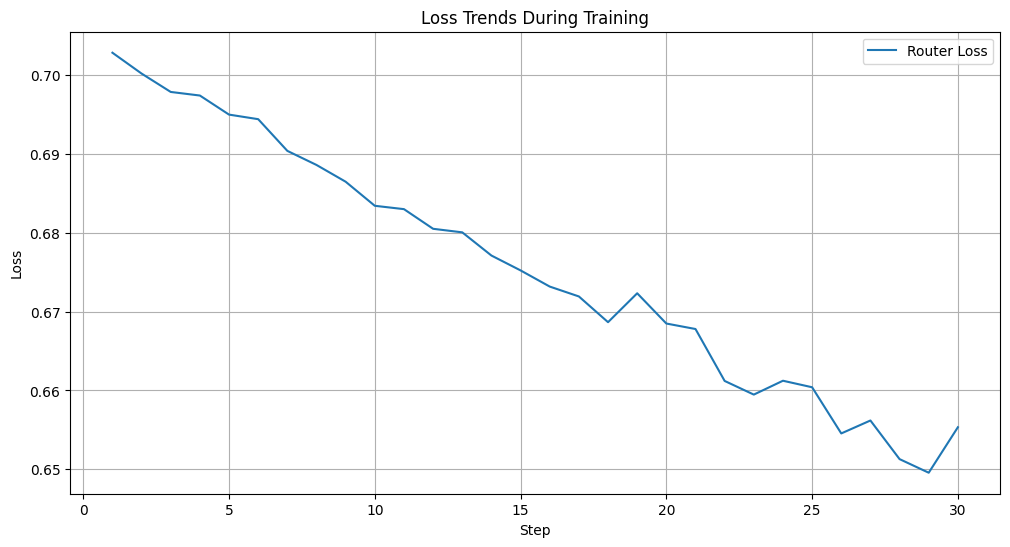

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
#plt.plot(step_list, loss_list, label="Total Loss")
#plt.plot(step_list, gen_loss_list, label="Generation Loss")
plt.plot(step_list, router_loss_list, label="Router Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Trends During Training")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt
epoch_loss_dict = defaultdict(list)

for epoch, loss in zip(epoch_list, loss_list):
    epoch_loss_dict[epoch].append(loss)

epoch_avg_losses = []
epochs = []

for epoch in sorted(epoch_loss_dict.keys()):
    losses = epoch_loss_dict[epoch]
    avg_loss = sum(losses) / len(losses)
    epoch_avg_losses.append(avg_loss)
    epochs.append(epoch)
    print(f"Epoch {epoch}: Average Loss = {avg_loss:.4f}")


Epoch 0: Average Loss = 7.0886
Epoch 1: Average Loss = 7.0862
Epoch 2: Average Loss = 7.0841


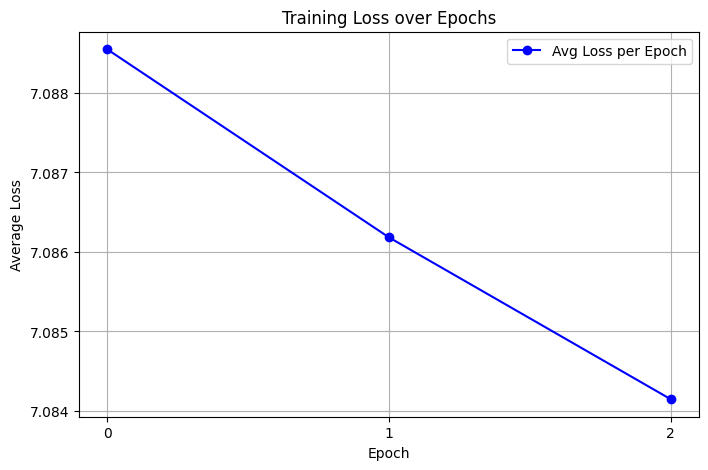

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, epoch_avg_losses, marker='o', color='blue', label="Avg Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss over Epochs")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.savefig("epoch_loss_curve.png")
plt.show()


In [ ]:
#router_logits = router(fused_hidden)
#task_loss = nn.CrossEntropyLoss()(router_logits, task_labels)

#total_loss = main_loss + alpha * task_loss  # combine generation + classification loss


In [ ]:
true_labels = []
predicted_experts = []
router = LearnedRouter()
router.load_state_dict(torch.load("modelSAGE/moe_router.pt", map_location=device))
router.to(device).eval()

moe_model = MoEModel([summ_model, qa_model], router)
moe_model.eval()

with torch.no_grad():
    for batch in train_dataloader:  # or use val_dataloader if available
        input_texts = batch['input_text']
        target_texts = batch['target_text']
        task_labels = batch['task_label']  # True labels: 0 or 1

        input_ids = t5_tokenizer(input_texts, return_tensors="pt", padding=True, truncation=True).input_ids.to(device)
        target_ids = t5_tokenizer(target_texts, return_tensors="pt", padding=True, truncation=True).input_ids.to(device)
        attention_mask = (input_ids != t5_tokenizer.pad_token_id).long().to(device)

        fusion_module = summ_fusion if task_labels[0] == 0 else qa_fusion

        bert_embs, t5_embs = get_aligned_embeddings(input_texts)
        fused_hidden = fusion_module(t5_embs.to(device), bert_embs.to(device)).detach()

        if fused_hidden.dim() == 2:
            fused_hidden = fused_hidden.unsqueeze(0)

        # Get only routing logits
        _, routing_logits = moe_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            fused_hidden=fused_hidden,
            labels=target_ids,
            task_labels=task_labels
        )

        pred_expert = torch.argmax(routing_logits, dim=-1).cpu().tolist()
        true = task_labels  # already a list

        predicted_experts.extend(pred_expert)
        true_labels.extend(true)

# Convert to numpy arrays
true_labels = np.array(true_labels)
predicted_experts = np.array(predicted_experts)


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


In [ ]:
cm = confusion_matrix(true_labels, predicted_experts)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(true_labels, predicted_experts, target_names=["Summarization", "QA"]))

Confusion Matrix:
[[25  0]
 [ 0 25]]

Classification Report:
               precision    recall  f1-score   support

Summarization       1.00      1.00      1.00        25
           QA       1.00      1.00      1.00        25

     accuracy                           1.00        50
    macro avg       1.00      1.00      1.00        50
 weighted avg       1.00      1.00      1.00        50



### r

In [ ]:
router = LearnedRouter()
router.load_state_dict(torch.load("modelSAGE/moe_router.pt", map_location=device))
router.to(device).eval()

moe_model = MoEModel([summ_model, qa_model], router)
moe_model.eval()

predictions = []
references = []

with torch.no_grad():
    for batch in train_dataloader:
        input_texts = batch["input_text"]
        target_texts = batch["target_text"]

        output, expert_idx = run_inference_without_label(input_texts)
        print("Generated Output:", output)

        predictions.append(output)
        references.append(target_texts)


In [ ]:
rouge_metric = evaluate.load("rouge")
results = rouge_metric.compute(predictions=predictions, references=references)
print("Final ROUGE scores:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

Final ROUGE scores:
rouge1: 0.6418
rouge2: 0.3503
rougeL: 0.5920
rougeLsum: 0.5901


In [ ]:
for i in range(50):
  print("\n",predictions[i])
  print("\n",references[i])

## test

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

summ_fusion = EncoderFusion()
summ_fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_summarize.pt", map_location=device))
summ_fusion.to(device).eval()

qa_fusion = EncoderFusion()
qa_fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_sqa.pt", map_location=device))
qa_fusion.to(device).eval()

qg_fusion = EncoderFusion()
qg_fusion.load_state_dict(torch.load("modelSAGE/encoder_fusion_sqg.pt", map_location=device))
qg_fusion.to(device).eval()

base_t5 = T5ForConditionalGeneration.from_pretrained("t5-base")
summ_model = PatchedT5(base_t5)
summ_model.load_state_dict(torch.load("modelSAGE/patched_t5_summarize.pt", map_location=device))
summ_model.to(device).eval()

qa_model = PatchedT5(base_t5)
qa_model.load_state_dict(torch.load("modelSAGE/patched_t5_sqa.pt", map_location=device))
qa_model.to(device).eval()

qg_model = PatchedT5(base_t5)
qg_model.load_state_dict(torch.load("modelSAGE/patched_t5_sqg.pt", map_location=device))
qg_model.to(device).eval()

router = LearnedRouter()
router.load_state_dict(torch.load("modelSAGE/moe_router.pt", map_location=device))
router.to(device).eval()

moe_model = MoEModel([summ_model, qa_model], router)
#moe_model = MoEModel([summ_model, qa_model, qg_model], router)


In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)

    fusion_outputs = []
    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        selected_expert = torch.argmax(route_logits).item()

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert


In [ ]:
input_text = "question:who use text messaging for communication context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)


[Selected Expert: 0]
Generated Output: Governmental and non-governmental organizations use text messaging for communication between colleagues


In [ ]:
input_text = "who use text messaging for communication context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

[Selected Expert: 0]
Generated Output: Governmental and non-governmental organizations use text messaging


In [ ]:
input_text = "Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

[Selected Expert: 0]
Generated Output: texting does not require the caller and recipient to be free at the same moment. e-mail and voicemail, texting does not require the caller and recipient to be free at the same moment. Advertisers and service providers use direct text marketing to send messages about promotions,


In [ ]:
input_text = "what permits communication even between busy individuals context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

[Selected Expert: 0]
Generated Output: texting does not require the caller and recipient to both be free at the same moment


In [ ]:
input_text = "question:what permits communication even between busy individuals context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

[Selected Expert: 0]
Generated Output: texting does not require the caller and recipient to both be free at the same moment


In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)

    fusion_outputs = []
    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]
        print(fusion_outputs)

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        print("\n",route_logits)
        selected_expert = torch.argmax(route_logits).item()
        print("\n",selected_expert)

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert

input_text = "question:what permits communication even between busy individuals context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

[tensor([[[-0.1349,  0.2290,  0.4027,  ..., -0.1255, -0.0514, -0.1922],
         [ 0.0103,  0.0717,  0.1256,  ...,  0.1332, -0.0891,  0.1093],
         [-0.0732,  0.0184,  0.0892,  ...,  0.0677, -0.0809, -0.0683],
         ...,
         [ 0.0450,  0.1185,  0.2678,  ..., -0.1325,  0.0341,  0.1126],
         [ 0.0241,  0.1670,  0.1506,  ...,  0.0330,  0.0945, -0.3011],
         [ 0.0825, -0.0291,  0.2361,  ..., -0.1031,  0.1856,  0.0557]]],
       grad_fn=<UnsqueezeBackward0>)]
[tensor([[[-0.1349,  0.2290,  0.4027,  ..., -0.1255, -0.0514, -0.1922],
         [ 0.0103,  0.0717,  0.1256,  ...,  0.1332, -0.0891,  0.1093],
         [-0.0732,  0.0184,  0.0892,  ...,  0.0677, -0.0809, -0.0683],
         ...,
         [ 0.0450,  0.1185,  0.2678,  ..., -0.1325,  0.0341,  0.1126],
         [ 0.0241,  0.1670,  0.1506,  ...,  0.0330,  0.0945, -0.3011],
         [ 0.0825, -0.0291,  0.2361,  ..., -0.1031,  0.1856,  0.0557]]],
       grad_fn=<UnsqueezeBackward0>), tensor([[[-0.0185, -0.1296,  0.0660,  

### ex

In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)

    fusion_outputs = []
    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        selected_expert = torch.argmax(route_logits).item()

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert


In [ ]:
input_text = "question:what permits communication even between busy individuals context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)

In [ ]:
def test_summarization(input_text):

    input_text = "summarize: " + input_text
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)

    fused_hidden = summ_fusion(t5_embs.to(device), bert_embs.to(device)).unsqueeze(0)

    summ_model.fused_hidden = fused_hidden
    output_ids = summ_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    print("[Summarization Expert Output]\n")
    print(t5_tokenizer.decode(output_ids[0], skip_special_tokens=True))


In [ ]:
def test_qa(question, context):
    input_text = f"question: {question} context: {context}"
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    bert_embs, t5_embs = get_aligned_embeddings(input_text)

    fused_hidden = qa_fusion(t5_embs.to(device), bert_embs.to(device)).unsqueeze(0)

    qa_model.fused_hidden = fused_hidden
    output_ids = qa_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    print("[QA Expert Output]\n")
    print(t5_tokenizer.decode(output_ids[0], skip_special_tokens=True))


In [ ]:
input_text = "Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
question = "what permits communication even between busy individuals"
context = "Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
test_summarization(input_text)
test_qa(question, context)

[Summarization Expert Output]

Text messages are used for personal, family, business, and social purposes . In the 2010s, the sending of short informal messages became an accepted part of many cultures . Text messages can also be used to interact with automated systems .
[QA Expert Output]

texting does not require the caller and recipient to both be free at the same moment


### text

In [ ]:
def read_file(filename):
    with open(filename, 'r') as file:
        return file.read()

plaintext = read_file('Plaintext.txt')

In [ ]:
from google.colab import files
from docx import Document

uploaded = files.upload()
doc = Document("report.docx")
full_text = []
for para in doc.paragraphs:
    full_text.append(para.text)
text = '\n'.join(full_text)

print(text)


In [ ]:
full_text[16]

'A clear example of this can be seen in the work of Sajja et al., who introduced the AI-powered Intelligent Assistant (AIIA)—a system that integrates with Learning Management Systems (LMS) to offer personalized support and context-aware content delivery. By analyzing learner performance and behavior, AIIA generates feedback and custom learning paths, significantly improving instructional quality. Similarly, Li et al. explored the use of Generative AI (GenAI) within Adaptive Learning (AL) systems, demonstrating how AI can generate practice questions, simulate interactive tutoring, and support multimodal learning. While promising, they also emphasize the need for human oversight to mitigate risks such as content hallucination and bias propagation.'

In [ ]:
input_text = "summarize this " + full_text[16]
output, expert_idx = run_inference_without_label(input_text)
print("Generated Output:", output)

In [ ]:
input_text = "question: what is this paper about? " + text
output, expert_idx = run_inference_without_label(input_text)
print("Generated Output:", output)

# ex

In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)
    bert_embs, t5_embs = get_aligned_embeddings(input_text)
    fusion_outputs = []

    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        #selected_expert = torch.argmax(route_logits[0]).item()
        scores = route_logits[0]  # shape [2, num_experts]
        # Get the best score overall
        max_score = scores.max()  # e.g., 0.5213
        selected_input_idx, selected_expert = torch.where(scores == max_score)

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert


In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    print("\n", decoder_input)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)
    print("\n", bert_embs)
    print("\n", t5_embs)

    fusion_outputs = []

    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        #selected_expert = torch.argmax(route_logits[0]).item()
        scores = route_logits[0]  # shape [2, num_experts]
        # Get the best score overall
        max_score = scores.max()  # e.g., 0.5213
        selected_input_idx, selected_expert = torch.where(scores == max_score)

    print("\n", route_logits)
    print("\n", selected_expert)

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert

input_text = "summarize this context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)


 tensor([[21603,    48,  2625,    10, 13598,    17,  4175,    33,   261,    21,
           525,     6,   384,     6,   268,     6,    11,   569,  3659,     5,
          3141,   138,    11,   529,    18, 18984,  2371,   169,  1499, 16324,
            21,  1901,   344,  6976,     5,    86,     8,  2735,     7,     6,
             8,  5657,    13,   710, 15347,  4175,  1632,    46,  4307,   294,
            13,   186,  9757,     6,    38,  2817,  2283,    28,   791,    53,
             5,  6306,   755,   908,   100,   656,  1499,    53,     3,     9,
          1704,    11,   514,   194,    12,  4521,    28,   803,     6,   384,
             6,    11,  6976,     6,   379,    16,  2625,     7,   213,     3,
             9,   580,   133,    36,  4840,    32,  6311,    42, 21001,    41,
            15,     5,   122,     5,     6,  3874,   182,  1480,    44,   706,
            42,   116,    80,  4054,     8,   119,   568,    19,  3164,    28,
           384,    42,   161,  1087,   137,  2792,

In [ ]:
print(input_text)

summarize this context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites o

In [ ]:
def run_inference_without_label(input_text):
    decoder_input = t5_tokenizer(input_text, return_tensors="pt").input_ids.to(device)

    print("\n", decoder_input)

    bert_embs, t5_embs = get_aligned_embeddings(input_text)
    print("\n", bert_embs.shape)
    print("\n", t5_embs.shape)

    fusion_outputs = []

    for fusion_module in [summ_fusion, qa_fusion]:
        fused = fusion_module(t5_embs.to(device), bert_embs.to(device))  # [seq_len, 768]
        fusion_outputs.append(fused.unsqueeze(0))  # [1, seq, 768]

    fused_batch = torch.stack(fusion_outputs).to(device)  # [2, seq, 768]

    with torch.no_grad():
        route_logits = router(fused_batch.mean(dim=1))  # [2, 768] → [2, num_experts]
        #selected_expert = torch.argmax(route_logits[0]).item()
        scores = route_logits[0]  # shape [2, num_experts]
        # Get the best score overall
        max_score = scores.max()  # e.g., 0.5213
        selected_input_idx, selected_expert = torch.where(scores == max_score)

    print("\n", route_logits)
    print("\n", selected_expert)

    expert_model = moe_model.expert_models[selected_expert]
    selected_fused_hidden = fused_batch[selected_expert].unsqueeze(0)  # [1, seq, 768]

    expert_model.fused_hidden = selected_fused_hidden

    output_ids = expert_model.generate(
        input_ids=decoder_input,
        attention_mask=(decoder_input != t5_tokenizer.pad_token_id).long().to(device),
        max_length=64,
        num_beams=4,
        early_stopping=True
    )

    output_text = t5_tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return output_text, selected_expert

input_text = "summarize this context:Text messages are used for personal, family, business, and social purposes. Governmental and non-governmental organizations use text messaging for communication between colleagues. In the 2010s, the sending of short informal messages became an accepted part of many cultures, as happened earlier with emailing.[5] This makes texting a quick and easy way to communicate with friends, family, and colleagues, including in contexts where a call would be impolite or inappropriate (e.g., calling very late at night or when one knows the other person is busy with family or work activities). Like e-mail and voicemail, and unlike calls (in which the caller hopes to speak directly with the recipient), texting does not require the caller and recipient to both be free at the same moment; this permits communication even between busy individuals. Text messages can also be used to interact with automated systems, for example, to order products or services from e-commerce websites or to participate in online contests. Advertisers and service providers use direct text marketing to send messages to mobile users about promotions, payment due dates, and other notifications instead of using postal mail, email, or voicemail."
output, expert_idx = run_inference_without_label(input_text)
print(f"[Selected Expert: {expert_idx}]")
print("Generated Output:", output)